# 线性模型 Baseline — Walk-Forward OLS

建立线性回归基线模型，作为后续 Lasso / Ridge / 逻辑回归的对照。

**流程**：截面预处理 → IC 初筛 → 共线性去重 → 逐日 OLS → EWM 平滑 → Walk-Forward 预测 → IC 评估

## Step 0 — 参数配置

### 参数表

| 参数 | 默认值 | 用途 |
|------|--------|------|
| `FOLD_DIR` | `00_fold切分/.../output/20260526` | fold CSV 目录 |
| `FOLD_ID` | `1` | 当前 fold 编号 |
| `LABEL_COL` | `FWD_RET_10D` | 标签列名 |
| `WINSORIZE_MAD` | `3.0` | MAD 倍数 |
| `IC_THRESHOLD` | `0.02` | IC 初筛阈值 |
| `T_STAT_THRESHOLD` | `2.0` | t 统计量阈值 |
| `CORR_THRESHOLD` | `0.7` | 共线性阈值 |
| `EWM_HALFLIFE` | `20` | β 平滑半衰期 |
| `OUTPUT_DIR` | `output` | 结果输出根目录 |

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import spearmanr
from typing import List, Dict, Tuple, Optional
import datetime as _dt
import warnings
warnings.filterwarnings("ignore")

# ===== 参数区 =====
FOLD_DIR        = Path("D:/quant/ML_teamwork/00_fold切分/01_train&test/output/20260526")
FOLD_ID         = 1
LABEL_COL       = "FWD_RET_10D"
WINSORIZE_MAD   = 3.0
IC_THRESHOLD    = 0.02
T_STAT_THRESHOLD= 2.0
CORR_THRESHOLD  = 0.7
EWM_HALFLIFE    = 20
OUTPUT_DIR      = Path("D:/quant/ML_teamwork/01_线性模型/01_线性模型baseline/output")

print("参数配置完成")
print(f"  Fold 目录: {FOLD_DIR}")
print(f"  Fold ID: {FOLD_ID}")
print(f"  标签列: {LABEL_COL}")
print(f"  Winsorize MAD: {WINSORIZE_MAD}")
print(f"  IC 阈值: {IC_THRESHOLD}  t 阈值: {T_STAT_THRESHOLD}")
print(f"  共线性阈值: {CORR_THRESHOLD}")
print(f"  EWM halflife: {EWM_HALFLIFE}")


参数配置完成
  Fold 目录: D:\quant\ML_teamwork\00_fold切分\01_train&test\output\20260526
  Fold ID: 1
  标签列: FWD_RET_10D
  Winsorize MAD: 3.0
  IC 阈值: 0.02  t 阈值: 2.0
  共线性阈值: 0.7
  EWM halflife: 20


## Step 1 — 函数定义

### 函数清单

| 函数 | 用途 |
|------|------|
| `load_fold` | 加载 fold CSV，返回 train/test DataFrame |
| `identify_columns` | 识别 ALPHA_* 特征列和 FWD_RET_* 标签列 |
| `cross_section_winsorize` | 逐日截面 MAD 去极值 |
| `cross_section_demean` | 逐日截面 demean（中性化降级） |
| `cross_section_zscore` | 逐日截面 z-score 标准化 |
| `compute_ic_panel` | 训练集逐日 Spearman IC 面板 |
| `summarize_ic` | IC 汇总统计（mean/std/t/pos_ratio） |
| `filter_by_ic` | 阈值过滤因子 |
| `spearman_union_find` | Spearman 相关矩阵 + 并查集分组 |
| `select_representatives` | 每组取 \|IC\| 最大代表 |
| `daily_ols_beta` | 逐日截面 OLS 拟合 |
| `smooth_beta_ewm` | β 时间序列 EWM 平滑 |
| `predict_walkforward` | Walk-forward 预测 |
| `evaluate_ic` | 日度 IC + 汇总评估 |

In [2]:
def load_fold(fold_dir: Path, fold_id: int) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """加载指定 fold 的训练/测试 CSV。

    输入:
        fold_dir: CSV 文件所在目录 (Path)
        fold_id: fold 编号 (int)

    输出:
        (train_df, test_df): 均已按 trade_date + ts_code 排序
    """
    tr = pd.read_csv(fold_dir / f"fold_{fold_id}_train.csv", parse_dates=["trade_date"])
    te = pd.read_csv(fold_dir / f"fold_{fold_id}_test.csv", parse_dates=["trade_date"])
    tr = tr.sort_values(["trade_date", "ts_code"]).reset_index(drop=True)
    te = te.sort_values(["trade_date", "ts_code"]).reset_index(drop=True)
    return tr, te


def identify_columns(df: pd.DataFrame) -> Tuple[List[str], str]:
    """识别特征列和标签列。

    输入:
        df: 因子表 DataFrame

    输出:
        (feature_cols, label_col): ALPHA_* 列名列表, 标签列名
    """
    feat = [c for c in df.columns if c.startswith("ALPHA_")]
    labels = [c for c in df.columns if c.startswith("FWD_RET_")]
    assert len(labels) >= 1, f"未找到 FWD_RET_* 标签列, cols={df.columns.tolist()}"
    label = labels[0]
    assert all(not c.startswith("FWD_RET_") for c in feat), "特征列含未来收益字段!"
    return feat, label


def cross_section_winsorize(df: pd.DataFrame, cols: List[str], n_mad: float = 3.0) -> pd.DataFrame:
    """逐日截面 MAD 去极值。

    输入:
        df: 含 trade_date 的 panel
        cols: 因子列名列表
        n_mad: MAD 倍数

    输出:
        同形 DataFrame, 列被截断到 [median - n*MAD, median + n*MAD]
    """
    def _winz(g):
        med = g[cols].median()
        mad = (g[cols] - med).abs().median() * 1.4826
        lo, hi = med - n_mad * mad, med + n_mad * mad
        g[cols] = g[cols].clip(lower=lo, upper=hi, axis=1)
        return g
    return df.groupby("trade_date", group_keys=False).apply(_winz)


def cross_section_demean(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    """逐日截面 demean（中性化降级，无行业/市值列时的替代方案）。

    输入:
        df: 含 trade_date 的 panel
        cols: 因子列名列表

    输出:
        同形 DataFrame, 每列减去当日截面均值
    """
    def _dm(g):
        g[cols] = g[cols] - g[cols].mean()
        return g
    return df.groupby("trade_date", group_keys=False).apply(_dm)


def cross_section_zscore(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    """逐日截面 z-score 标准化。

    输入:
        df: 含 trade_date 的 panel
        cols: 因子列名列表

    输出:
        同形 DataFrame, 每列 (x - mean) / std
    """
    def _zs(g):
        g[cols] = (g[cols] - g[cols].mean()) / g[cols].std(ddof=0).replace(0, 1)
        return g
    return df.groupby("trade_date", group_keys=False).apply(_zs)


In [3]:
def compute_ic_panel(df: pd.DataFrame, feat_cols: List[str], label_col: str) -> pd.DataFrame:
    """逐日截面 Spearman IC 面板。

    输入:
        df: 含 trade_date 的 panel
        feat_cols: 特征列名列表
        label_col: 标签列名

    输出:
        DataFrame index=trade_date, columns=feat_cols, 值为日度 Spearman IC
    """
    out = {}
    for d, g in df.groupby("trade_date"):
        out[d] = g[feat_cols].corrwith(g[label_col], method="spearman")
    return pd.DataFrame(out).T.sort_index()


def summarize_ic(ic_panel: pd.DataFrame) -> pd.DataFrame:
    """IC 面板汇总统计。

    输入:
        ic_panel: compute_ic_panel 输出, index=date, columns=feat

    输出:
        DataFrame index=feat, columns=[ic_mean, ic_std, t_stat, pos_ratio]
    """
    mu = ic_panel.mean()
    sd = ic_panel.std()
    n = ic_panel.notna().sum()
    t = mu / sd * np.sqrt(n)
    pos = (ic_panel > 0).mean()
    return pd.DataFrame({"ic_mean": mu, "ic_std": sd, "t_stat": t, "pos_ratio": pos})


def filter_by_ic(ic_summary: pd.DataFrame, ic_th: float = 0.02, t_th: float = 2.0) -> List[str]:
    """按 |IC| 和 |t| 阈值过滤因子。

    输入:
        ic_summary: summarize_ic 输出
        ic_th: |IC mean| 下限
        t_th: |t_stat| 下限

    输出:
        通过筛选的因子名列表
    """
    mask = (ic_summary["ic_mean"].abs() > ic_th) & (ic_summary["t_stat"].abs() > t_th)
    return ic_summary.index[mask].tolist()


def spearman_union_find(df: pd.DataFrame, cols: List[str], corr_th: float = 0.7) -> List[List[str]]:
    """Spearman 相关矩阵 + 并查集分组, 将 |ρ| > corr_th 的因子聚为一组。

    输入:
        df: train DataFrame
        cols: 候选因子列名
        corr_th: 相关系数阈值

    输出:
        list[list[str]], 每个子表是一组共线因子
    """
    corr = df[cols].corr(method="spearman").abs().values
    np.fill_diagonal(corr, 0)
    n = len(cols)
    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[ra] = rb

    rows, ccols = np.where(corr > corr_th)
    for a, b in zip(rows, ccols):
        if a < b:
            union(a, b)

    groups = {}
    for i, c in enumerate(cols):
        groups.setdefault(find(i), []).append(c)
    return list(groups.values())


def select_representatives(groups: List[List[str]], ic_summary: pd.DataFrame) -> List[str]:
    """每组共线因子中选 |IC mean| 最大的作为代表。

    输入:
        groups: spearman_union_find 输出
        ic_summary: summarize_ic 输出

    输出:
        代表因子名列表
    """
    reps = []
    for grp in groups:
        if len(grp) == 1:
            reps.append(grp[0])
        else:
            best = ic_summary.loc[grp, "ic_mean"].abs().idxmax()
            reps.append(best)
    return reps


def daily_ols_beta(df: pd.DataFrame, x_cols: List[str], y_col: str,
                   add_const: bool = True) -> pd.DataFrame:
    """逐日截面 OLS, 返回 β 时间序列。

    输入:
        df: 含 trade_date 的 panel
        x_cols: 特征列名
        y_col: 标签列名
        add_const: 是否加截距项

    输出:
        DataFrame index=trade_date, columns=x_cols (+ const)
    """
    rows = []
    for d, g in df.groupby("trade_date"):
        X = g[x_cols].values
        if add_const:
            X = np.column_stack([X, np.ones(len(X))])
        y = g[y_col].values
        mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
        if mask.sum() < X.shape[1] + 5:
            continue
        beta, *_ = np.linalg.lstsq(X[mask], y[mask], rcond=None)
        rows.append((d, beta))
    cols_out = x_cols + (["const"] if add_const else [])
    idx = [r[0] for r in rows]
    arr = np.array([r[1] for r in rows])
    return pd.DataFrame(arr, index=idx, columns=cols_out)


def smooth_beta_ewm(beta_df: pd.DataFrame, halflife: int = 20) -> pd.DataFrame:
    """β 时间序列 EWM 平滑。

    输入:
        beta_df: daily_ols_beta 输出, index=date
        halflife: EWM 半衰期

    输出:
        同形 DataFrame, 每列 EWM 平滑
    """
    return beta_df.ewm(halflife=halflife, adjust=False).mean()


def predict_walkforward(test_df: pd.DataFrame, x_cols: List[str],
                        beta_ewm_shifted: pd.DataFrame,
                        add_const: bool = True) -> pd.DataFrame:
    """测试日 t 用 β_ewm[t-1] 预测。

    输入:
        test_df: 已预处理的测试集 panel
        x_cols: 特征列名
        beta_ewm_shifted: EWM 平滑且已 shift(1) 的 β
        add_const: 是否加截距

    输出:
        DataFrame [trade_date, ts_code, y_pred, y_true]
    """
    out = []
    for d, g in test_df.groupby("trade_date"):
        if d not in beta_ewm_shifted.index:
            continue
        b = beta_ewm_shifted.loc[d]
        if b.isna().any():
            continue
        X = g[x_cols].values
        if add_const:
            X = np.column_stack([X, np.ones(len(X))])
        yp = X @ b.values
        out.append(pd.DataFrame({
            "trade_date": d,
            "ts_code": g["ts_code"].values,
            "y_pred": yp,
            "y_true": g["FWD_RET_10D"].values,
        }))
    return pd.concat(out, ignore_index=True)


def evaluate_ic(pred_df: pd.DataFrame, pred_col: str = "y_pred",
                true_col: str = "y_true") -> Tuple[pd.Series, dict]:
    """日度截面 Spearman IC + 汇总指标。

    输入:
        pred_df: predict_walkforward 输出长表
        pred_col: 预测值列名
        true_col: 真实值列名

    输出:
        (ic_series, summary_dict):
            ic_series: index=trade_date, value=Spearman ρ
            summary_dict: ic_mean / ic_std / ic_ir / pos_ratio / n_days
    """
    ics = []
    for d, g in pred_df.groupby("trade_date"):
        m = g[[pred_col, true_col]].dropna()
        if len(m) < 10:
            continue
        rho, _ = spearmanr(m[pred_col], m[true_col])
        ics.append((d, rho))
    ic_s = pd.Series(dict(ics)).sort_index()
    summary = {
        "ic_mean":   ic_s.mean(),
        "ic_std":    ic_s.std(),
        "ic_ir":     ic_s.mean() / ic_s.std() * np.sqrt(252 / 10) if ic_s.std() > 0 else 0.0,
        "pos_ratio": (ic_s > 0).mean(),
        "n_days":    len(ic_s),
    }
    return ic_s, summary


print("[OK] Step 1 全部函数定义完成")


[OK] Step 1 全部函数定义完成


## Step 2 — 加载 Fold 数据

### 该 Step 涉及参数

| 参数 | 来源 | 用途 |
|------|------|------|
| `FOLD_DIR` | Step 0 | fold CSV 目录 |
| `FOLD_ID` | Step 0 | fold 编号 |

In [4]:
train_df, test_df = load_fold(FOLD_DIR, FOLD_ID)
print(f"Fold {FOLD_ID} 加载完成")
print(f"  Train: {train_df.shape[0]:,} rows, {train_df['trade_date'].nunique()} 日, "
      f"{train_df['trade_date'].min().date()} ~ {train_df['trade_date'].max().date()}")
print(f"  Test:  {test_df.shape[0]:,} rows, {test_df['trade_date'].nunique()} 日, "
      f"{test_df['trade_date'].min().date()} ~ {test_df['trade_date'].max().date()}")

feature_cols, label_col = identify_columns(train_df)
print(f"\n特征列: {len(feature_cols)} 列 (ALPHA_1 ~ ALPHA_{len(feature_cols)})")
print(f"标签列: {label_col}")
print(f"标签缺失率 — train: {train_df[label_col].isna().mean():.4%}  test: {test_df[label_col].isna().mean():.4%}")


Fold 1 加载完成
  Train: 282,719 rows, 976 日, 2015-12-31 ~ 2019-12-31
  Test:  32,331 rows, 108 日, 2020-01-16 ~ 2020-07-01

特征列: 230 列 (ALPHA_1 ~ ALPHA_230)
标签列: FWD_RET_10D
标签缺失率 — train: 0.0000%  test: 0.0000%


## Step 3 — 截面预处理

逐日截面: MAD winsorize → demean (中性化降级) → z-score 标准化。

### 该 Step 涉及参数

| 参数 | 来源 | 用途 |
|------|------|------|
| `WINSORIZE_MAD` | Step 0 | MAD 去极值倍数 |

> 无 industry / size / mkt_cap 列, 中性化降级为截面 demean。

In [5]:
# Step 3a: Winsorize
train_df = cross_section_winsorize(train_df, feature_cols, WINSORIZE_MAD)
test_df  = cross_section_winsorize(test_df,  feature_cols, WINSORIZE_MAD)
print("[Step 3a] Winsorize 完成")

# Step 3b: Demean (中性化降级)
train_df = cross_section_demean(train_df, feature_cols)
test_df  = cross_section_demean(test_df,  feature_cols)
print("[Step 3b] Demean 完成")

# Step 3c: Z-score
train_df = cross_section_zscore(train_df, feature_cols)
test_df  = cross_section_zscore(test_df,  feature_cols)
print("[Step 3c] Z-score 完成")
print(f"  预处理后 train: {train_df.shape}  test: {test_df.shape}")


[Step 3a] Winsorize 完成
[Step 3b] Demean 完成
[Step 3c] Z-score 完成
  预处理后 train: (282719, 233)  test: (32331, 233)


## Step 4 — 因子 IC 初筛

训练区间内每日 Spearman(ALPHA_i, FWD_RET_10D), 保留 |IC|>threshold 且 |t|>threshold 的因子。

### 该 Step 涉及参数

| 参数 | 来源 | 用途 |
|------|------|------|
| `IC_THRESHOLD` | Step 0 | |IC mean| 下限 |
| `T_STAT_THRESHOLD` | Step 0 | |t_stat| 下限 |

> 只用训练集计算 IC, 保留列表应用到测试集。

In [6]:
ic_panel = compute_ic_panel(train_df, feature_cols, label_col)
ic_summary = summarize_ic(ic_panel)
kept_ic = filter_by_ic(ic_summary, IC_THRESHOLD, T_STAT_THRESHOLD)
print(f"IC 面板: {ic_panel.shape[0]} 日 x {ic_panel.shape[1]} 因子")
print(f"通过 |IC|>{IC_THRESHOLD} & |t|>{T_STAT_THRESHOLD}: {len(kept_ic)} / {len(feature_cols)}")
print(f"\nIC 汇总 (前10):")
display(ic_summary.loc[kept_ic].head(10).round(4) if kept_ic else "无因子通过 IC 筛选")


IC 面板: 976 日 x 230 因子
通过 |IC|>0.02 & |t|>2.0: 76 / 230

IC 汇总 (前10):


,ic_mean,ic_std,t_stat,pos_ratio
ALPHA_1,0.0274,0.0951,8.9981,0.5984
ALPHA_3,-0.0214,0.1614,-4.1328,0.4682
ALPHA_4,0.0322,0.1105,9.0976,0.6291
ALPHA_11,-0.0236,0.1667,-4.4283,0.4805
ALPHA_12,0.0207,0.1125,5.7369,0.5871
ALPHA_13,0.0373,0.0898,12.9866,0.6762
ALPHA_19,-0.0225,0.1771,-3.9674,0.4621
ALPHA_21,0.0277,0.1647,5.2625,0.5471
ALPHA_26,0.0285,0.0828,10.7383,0.6301
ALPHA_29,0.0327,0.1505,6.7965,0.5748


## Step 5 — 共线性去重

训练集堆叠后计算 ALPHA 间 Spearman 相关矩阵, |ρ|>threshold 连边, 并查集找组, 每组保留 |IC| 最大的因子。

### 该 Step 涉及参数

| 参数 | 来源 | 用途 |
|------|------|------|
| `CORR_THRESHOLD` | Step 0 | 共线性阈值 |

> 只用训练集计算, 分组结果应用到测试集。

In [7]:
if len(kept_ic) == 0:
    kept_final = []
    groups = []
    print("[WARNING] 无因子通过 IC 筛选, 跳过共线性去重")
else:
    groups = spearman_union_find(train_df, kept_ic, CORR_THRESHOLD)
    kept_final = select_representatives(groups, ic_summary)
    print(f"共线性分组数: {len(groups)} (阈值 |ρ|>{CORR_THRESHOLD})")
    print(f"去重后保留: {len(kept_final)} 个因子")
    # 打印各组详情
    for i, grp in enumerate(groups):
        rep = select_representatives([grp], ic_summary)[0]
        if len(grp) > 1:
            print(f"  Group {i+1}: {len(grp)} factors -> {rep} (|IC|={ic_summary.loc[rep, 'ic_mean']:.4f})")
    print(f"\n最终因子列表 ({len(kept_final)}): {kept_final}")


共线性分组数: 38 (阈值 |ρ|>0.7)
去重后保留: 38 个因子
  Group 2: 4 factors -> ALPHA_182 (|IC|=0.0289)
  Group 3: 2 factors -> ALPHA_4 (|IC|=0.0322)
  Group 5: 2 factors -> ALPHA_13 (|IC|=0.0373)
  Group 6: 13 factors -> ALPHA_94 (|IC|=-0.0306)
  Group 7: 2 factors -> ALPHA_26 (|IC|=0.0285)
  Group 9: 3 factors -> ALPHA_69 (|IC|=-0.0310)
  Group 10: 2 factors -> ALPHA_34 (|IC|=0.0571)
  Group 12: 2 factors -> ALPHA_51 (|IC|=0.0432)
  Group 13: 3 factors -> ALPHA_76 (|IC|=-0.0272)
  Group 15: 3 factors -> ALPHA_79 (|IC|=-0.0398)
  Group 16: 5 factors -> ALPHA_78 (|IC|=0.0372)
  Group 17: 2 factors -> ALPHA_83 (|IC|=0.0310)
  Group 18: 3 factors -> ALPHA_90 (|IC|=0.0273)
  Group 19: 2 factors -> ALPHA_98 (|IC|=0.0483)
  Group 20: 4 factors -> ALPHA_112 (|IC|=0.0385)
  Group 26: 2 factors -> ALPHA_140 (|IC|=-0.0375)

最终因子列表 (38): ['ALPHA_1', 'ALPHA_182', 'ALPHA_4', 'ALPHA_12', 'ALPHA_13', 'ALPHA_94', 'ALPHA_26', 'ALPHA_29', 'ALPHA_69', 'ALPHA_34', 'ALPHA_50', 'ALPHA_51', 'ALPHA_76', 'ALPHA_61', 'ALPHA_79'

## Step 6 — 逐日截面 OLS

训练集 + 测试集分别逐日 OLS 拟合, 得 β 时间序列。

> 训练 β 用于 EWM 主体, 测试 β 仅为 EWM 提供末尾增量, 不直接用于预测。
> `daily_ols_beta` 内置最小样本数过滤 (N < K+5 跳过)。

In [8]:
if len(kept_final) == 0:
    print("[ERROR] 无保留因子, 无法继续")
else:
    x_cols = kept_final
    print(f"使用 {len(x_cols)} 个因子进行逐日 OLS")
    
    beta_train = daily_ols_beta(train_df, x_cols, label_col, add_const=True)
    beta_test  = daily_ols_beta(test_df,  x_cols, label_col, add_const=True)
    
    print(f"β_train: {beta_train.shape[0]} 日 x {beta_train.shape[1]} 特征")
    print(f"β_test:  {beta_test.shape[0]} 日 x {beta_test.shape[1]} 特征")
    print(f"\nβ_train 前5日:\n{beta_train.head().round(4)}")


使用 38 个因子进行逐日 OLS
β_train: 976 日 x 39 特征
β_test:  108 日 x 39 特征

β_train 前5日:
            ALPHA_1  ALPHA_182  ALPHA_4  ALPHA_12  ALPHA_13  ALPHA_94  \
2015-12-31   0.0068     0.0043   0.0140   -0.0095   -0.0097    0.0068   
2016-01-04  -0.0003     0.0001   0.0115    0.0068   -0.0043    0.0117   
2016-01-05   0.0034     0.0093   0.0096    0.0102   -0.0075    0.0137   
2016-01-06   0.0010     0.0011   0.0028   -0.0022    0.0015    0.0112   
2016-01-07   0.0046     0.0046  -0.0023    0.0109   -0.0036    0.0114   

            ALPHA_26  ALPHA_29  ALPHA_69  ALPHA_34  ...  ALPHA_157  ALPHA_162  \
2015-12-31   -0.0032   -0.0011   -0.0006   -0.0021  ...     0.0000    -0.0013   
2016-01-04   -0.0037    0.0022    0.0067    0.0158  ...     0.0000    -0.0045   
2016-01-05    0.0003    0.0007   -0.0021    0.0126  ...     0.0041    -0.0002   
2016-01-06    0.0029    0.0041   -0.0018    0.0191  ...    -0.0000     0.0008   
2016-01-07   -0.0026    0.0062   -0.0014    0.0211  ...    -0.0000     0.0006 

## Step 7 — β 时间序列 EWM 平滑

拼接 train + test β → 全区间 EWM → shift(1), 确保 t 日预测只用 t-1 及之前的信息。

### 该 Step 涉及参数

| 参数 | 来源 | 用途 |
|------|------|------|
| `EWM_HALFLIFE` | Step 0 | EWM 半衰期 |

> `shift(1)` 是 walk-forward 防未来信息泄漏的核心操作。

In [9]:
if len(kept_final) > 0:
    beta_all = pd.concat([beta_train, beta_test]).sort_index()
    beta_ewm = smooth_beta_ewm(beta_all, EWM_HALFLIFE)
    beta_for_pred = beta_ewm.shift(1)
    
    print(f"全区间 β: {beta_all.shape[0]} 日")
    print(f"EWM (halflife={EWM_HALFLIFE}) 后 β_for_pred 可用日: {beta_for_pred.dropna(how='all').shape[0]}")
    print(f"\nβ_ewm 尾部 (最后5日):\n{beta_ewm.tail().round(4)}")


全区间 β: 1084 日
EWM (halflife=20) 后 β_for_pred 可用日: 1083

β_ewm 尾部 (最后5日):
            ALPHA_1  ALPHA_182  ALPHA_4  ALPHA_12  ALPHA_13  ALPHA_94  \
2020-06-23   0.0023    -0.0019   0.0007    0.0018    0.0013    0.0039   
2020-06-24   0.0021    -0.0015  -0.0002    0.0025    0.0019    0.0047   
2020-06-29   0.0023    -0.0017  -0.0008    0.0012    0.0023    0.0043   
2020-06-30   0.0018    -0.0019  -0.0009    0.0012    0.0026    0.0040   
2020-07-01   0.0019    -0.0024  -0.0012    0.0014    0.0022    0.0042   

            ALPHA_26  ALPHA_29  ALPHA_69  ALPHA_34  ...  ALPHA_157  ALPHA_162  \
2020-06-23   -0.0012    0.0037   -0.0038   -0.0017  ...     0.0006    -0.0016   
2020-06-24   -0.0009    0.0029   -0.0026   -0.0024  ...     0.0006    -0.0026   
2020-06-29   -0.0003    0.0025   -0.0024   -0.0035  ...     0.0005    -0.0021   
2020-06-30    0.0010    0.0026   -0.0017   -0.0047  ...     0.0005    -0.0022   
2020-07-01    0.0018    0.0024   -0.0013   -0.0049  ...     0.0015    -0.0021   

 

## Step 8 — 测试集 Walk-Forward 预测

测试日 t 使用 β_ewm[t-1] 预测: `y_pred[t] = X[t] @ β_ewm[t-1]`。

> 这是 walk-forward 的核心: 预测时点 t 只能看到 t-1 及之前的信息。

In [10]:
if len(kept_final) > 0:
    pred_df = predict_walkforward(test_df, x_cols, beta_for_pred, add_const=True)
    print(f"预测结果: {pred_df.shape[0]:,} 行")
    print(f"  日期数: {pred_df['trade_date'].nunique()}")
    print(f"  y_pred 范围: [{pred_df['y_pred'].min():.4f}, {pred_df['y_pred'].max():.4f}]")
    print(f"  y_true 范围: [{pred_df['y_true'].min():.4f}, {pred_df['y_true'].max():.4f}]")
    display(pred_df.head(10))
else:
    pred_df = pd.DataFrame()
    print("[ERROR] 无预测结果")


预测结果: 32,331 行
  日期数: 108
  y_pred 范围: [-0.0800, 0.1041]
  y_true 范围: [-0.3471, 1.0951]


,trade_date,ts_code,y_pred,y_true
0,2020-01-16,000001.SZ,0.041648,-0.104715
1,2020-01-16,000002.SZ,0.037759,-0.099247
2,2020-01-16,000063.SZ,0.032680,0.040631
3,2020-01-16,000069.SZ,0.032996,-0.142480
4,2020-01-16,000100.SZ,NaN,0.158859
5,2020-01-16,000157.SZ,0.032901,-0.103604
6,2020-01-16,000166.SZ,NaN,-0.111776
7,2020-01-16,000333.SZ,NaN,-0.114482
8,2020-01-16,000338.SZ,NaN,-0.066480
9,2020-01-16,000413.SZ,0.006545,-0.156627


## Step 9 — IC 评估

测试集每日截面 Spearman(y_pred, y_true), 输出 IC 序列与汇总指标。

**汇总指标**:
- `ic_mean`: 日均 IC
- `ic_std`: IC 标准差
- `ic_ir`: 年化 IC IR (sqrt(252/10) * ic_mean / ic_std)
- `pos_ratio`: IC > 0 占比
- `n_days`: 有效测试日数

=== IC 汇总 ===
  ic_mean: 0.135744
  ic_std: 0.120412
  ic_ir: 5.659149
  pos_ratio: 0.879630
  n_days: 108

IC 序列 (108 日):
  Min:  -0.1592
  Max:  0.4713
  Mean: 0.1357


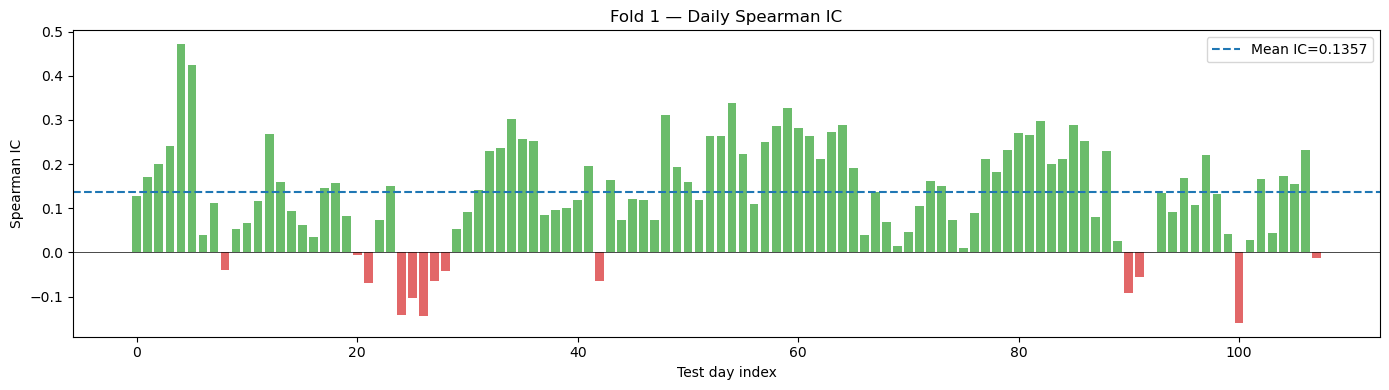

In [11]:
if len(pred_df) > 0:
    ic_series, ic_summary_dict = evaluate_ic(pred_df)
    
    print("=== IC 汇总 ===")
    for k, v in ic_summary_dict.items():
        print(f"  {k}: {v:.6f}" if isinstance(v, float) else f"  {k}: {v}")
    
    # 简易 IC 序列图 (文本)
    print(f"\nIC 序列 ({len(ic_series)} 日):")
    print(f"  Min:  {ic_series.min():.4f}")
    print(f"  Max:  {ic_series.max():.4f}")
    print(f"  Mean: {ic_series.mean():.4f}")
    
    # ASCII 简易走势
    try:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(14, 4))
        ax.bar(range(len(ic_series)), ic_series.values, color=['#d62728' if v < 0 else '#2ca02c' for v in ic_series.values], alpha=0.7)
        ax.axhline(y=0, color='black', linewidth=0.5)
        ax.axhline(y=ic_series.mean(), color='#1f77b4', linestyle='--', label=f"Mean IC={ic_series.mean():.4f}")
        ax.set_title(f"Fold {FOLD_ID} — Daily Spearman IC")
        ax.set_xlabel("Test day index")
        ax.set_ylabel("Spearman IC")
        ax.legend()
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"  [图表跳过] {e}")
else:
    print("[ERROR] 无预测结果, 跳过 IC 评估")
    ic_series = pd.Series(dtype=float)
    ic_summary_dict = {}


## Step 10 — 持久化输出

保存预测结果、IC 序列、汇总指标、保留因子列表、β 历史到 `output/{date}/`。

### 产出文件

| 文件 | 内容 |
|------|------|
| `fold_{k}_y_pred.parquet` | 长表: trade_date, ts_code, y_pred, y_true |
| `fold_{k}_ic_series.csv` | index=trade_date, value=daily IC |
| `fold_{k}_summary.csv` | ic_mean / ic_std / ic_ir / pos_ratio / n_days / n_features_kept |
| `fold_{k}_kept_factors.txt` | IC 筛选 + 共线去重后保留的因子名 |
| `fold_{k}_beta_history.parquet` | β 时间序列 (训练+测试拼接, 平滑前) |

In [ ]:
run_date = _dt.date.today().strftime("%Y%m%d")
out_dir = OUTPUT_DIR / run_date
out_dir.mkdir(parents=True, exist_ok=True)
print(f"输出目录: {out_dir}")

if len(pred_df) > 0:
    # 1) y_pred
    pred_path = out_dir / f"fold_{FOLD_ID}_y_pred.parquet"
    pred_df.to_parquet(pred_path, index=False)
    print(f"[SAVED] {pred_path}  ({pred_df.shape[0]:,} rows)")
    
    # 2) IC series
    ic_path = out_dir / f"fold_{FOLD_ID}_ic_series.csv"
    ic_series.to_csv(ic_path, header=["ic"])
    print(f"[SAVED] {ic_path}")
    
    # 3) Summary
    summary_row = {
        "ic_mean": ic_summary_dict.get("ic_mean", np.nan),
        "ic_std": ic_summary_dict.get("ic_std", np.nan),
        "ic_ir": ic_summary_dict.get("ic_ir", np.nan),
        "pos_ratio": ic_summary_dict.get("pos_ratio", np.nan),
        "n_days": ic_summary_dict.get("n_days", 0),
        "n_features_kept": len(kept_final),
    }
    summary_path = out_dir / f"fold_{FOLD_ID}_summary.csv"
    pd.DataFrame([summary_row]).to_csv(summary_path, index=False)
    print(f"[SAVED] {summary_path}")
    
    # 4) Kept factors
    factors_path = out_dir / f"fold_{FOLD_ID}_kept_factors.txt"
    factors_path.write_text("\n".join(kept_final))
    print(f"[SAVED] {factors_path}  ({len(kept_final)} factors)")
    
    # 5) Beta history (平滑前, train+test 拼接)
    beta_path = out_dir / f"fold_{FOLD_ID}_beta_history.parquet"
    beta_all.to_parquet(beta_path)
    print(f"[SAVED] {beta_path}  ({beta_all.shape[0]} days x {beta_all.shape[1]} cols)")
    
    print(f"\n[DONE] Fold {FOLD_ID} 全部输出完成 -> {out_dir}")
else:
    print("[ERROR] 无有效预测结果, 跳过输出")


输出目录: D:\quant\ML_teamwork\01_线性模型\01_线性模型baseline\output\20260526
[SAVED] D:\quant\ML_teamwork\01_线性模型\01_线性模型baseline\output\20260526\fold_1_y_pred.parquet  (32,331 rows)
[SAVED] D:\quant\ML_teamwork\01_线性模型\01_线性模型baseline\output\20260526\fold_1_ic_series.csv
[SAVED] D:\quant\ML_teamwork\01_线性模型\01_线性模型baseline\output\20260526\fold_1_summary.csv
[SAVED] D:\quant\ML_teamwork\01_线性模型\01_线性模型baseline\output\20260526\fold_1_kept_factors.txt  (38 factors)
[SAVED] D:\quant\ML_teamwork\01_线性模型\01_线性模型baseline\output\20260526\fold_1_beta_history.parquet  (1084 days x 39 cols)

[DONE] Fold 1 全部输出完成 -> D:\quant\ML_teamwork\01_线性模型\01_线性模型baseline\output\20260526


: 